# 🍊 The Orange Problem — Data Exploration & Preprocessing
**Dataset:** HuggingFaceM4/ChartQA  
**Goal:** Understand the dataset structure, visualize samples, and validate preprocessing before training.

In [2]:
!pip install -q datasets pillow matplotlib

## 1. Load the Dataset

In [3]:
from datasets import load_dataset

train_ds = load_dataset("HuggingFaceM4/ChartQA", split="train")
val_ds   = load_dataset("HuggingFaceM4/ChartQA", split="val")
test_ds  = load_dataset("HuggingFaceM4/ChartQA", split="test")

print(f"Train: {len(train_ds)} samples")
print(f"Val:   {len(val_ds)} samples")
print(f"Test:  {len(test_ds)} samples")
print(f"\nColumns: {train_ds.column_names}")

README.md:   0%|          | 0.00/852 [00:00<?, ?B/s]

data/train-00000-of-00003-49492f364babfa(…):   0%|          | 0.00/219M [00:00<?, ?B/s]

data/train-00001-of-00003-7302bae5e425bb(…):   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00002-of-00003-194c9400785577(…):   0%|          | 0.00/315M [00:00<?, ?B/s]

data/val-00000-of-00001-0f11003c77497969(…):   0%|          | 0.00/50.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e2cd0b7a0f9eb20(…):   0%|          | 0.00/68.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28299 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Train: 28299 samples
Val:   1920 samples
Test:  2500 samples

Columns: ['image', 'query', 'label', 'human_or_machine']


## 2. Inspect Raw Samples

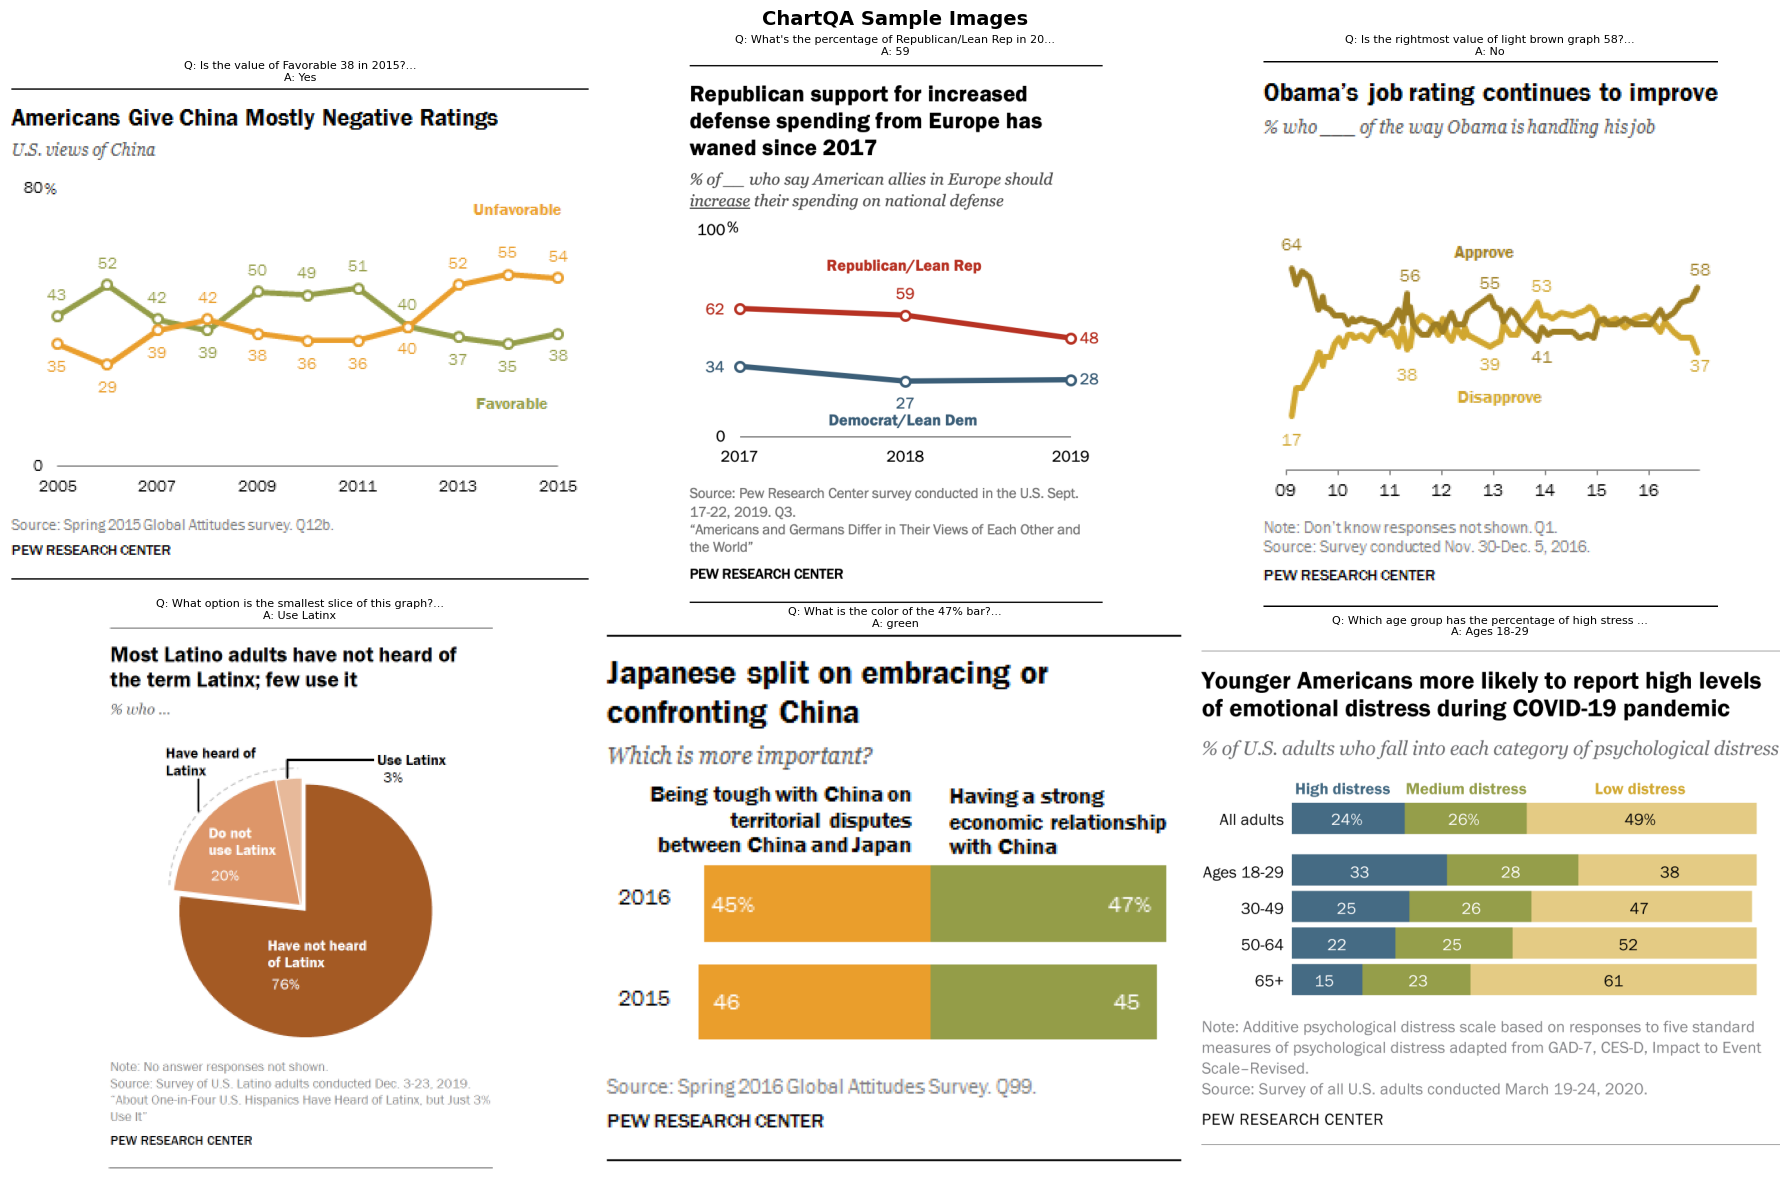

Saved: sample_images.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import numpy as np

# Show 6 random samples: image + question + answer
indices = [0, 50, 200, 500, 1000, 2000]

fig = plt.figure(figsize=(18, 12))
for i, idx in enumerate(indices):
    sample = train_ds[idx]
    ax = fig.add_subplot(2, 3, i+1)
    ax.imshow(sample['image'])
    label = sample['label'][0] if isinstance(sample['label'], list) else sample['label']
    ax.set_title(f"Q: {sample['query'][:50]}...\nA: {label}", fontsize=8, wrap=True)
    ax.axis('off')

plt.suptitle("ChartQA Sample Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=100, bbox_inches='tight')
plt.show()
print("Saved: sample_images.png")

## 3. Analyze Image Sizes

Width  — min: 200px, max: 918px, avg: 393px
Height — min: 281px, max: 1193px, avg: 447px


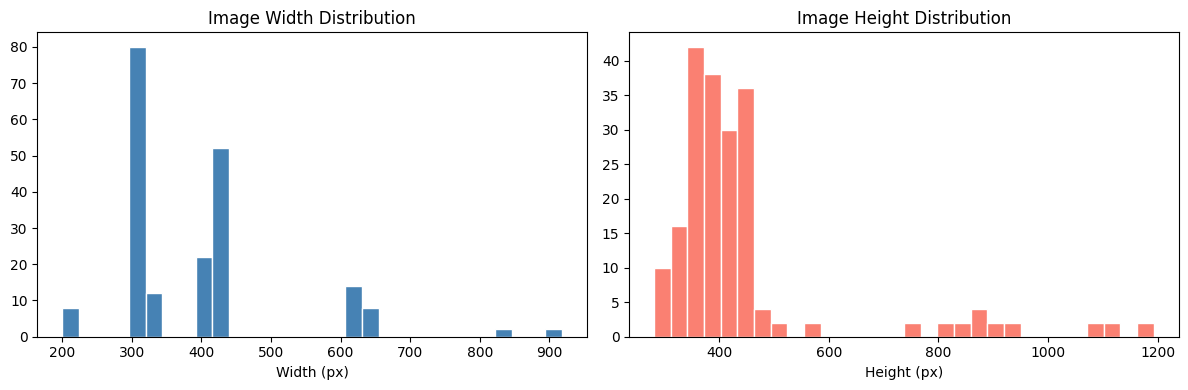

In [5]:
# Sample 200 images to understand size distribution
widths, heights = [], []
for i in range(0, min(200, len(train_ds))):
    img = train_ds[i]['image']
    if isinstance(img, Image.Image):
        w, h = img.size
    else:
        arr = np.array(img)
        h, w = arr.shape[:2]
    widths.append(w)
    heights.append(h)

print(f"Width  — min: {min(widths)}px, max: {max(widths)}px, avg: {int(sum(widths)/len(widths))}px")
print(f"Height — min: {min(heights)}px, max: {max(heights)}px, avg: {int(sum(heights)/len(heights))}px")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
plt.tight_layout()
plt.savefig("image_size_distribution.png", dpi=100)
plt.show()

## 4. Analyze Question & Answer Lengths

Question length — avg: 11.1 words, max: 34
Answer length   — avg: 1.1 words, max: 15

→ Answers are very short (mostly 1-3 words/numbers). Good for VQA.


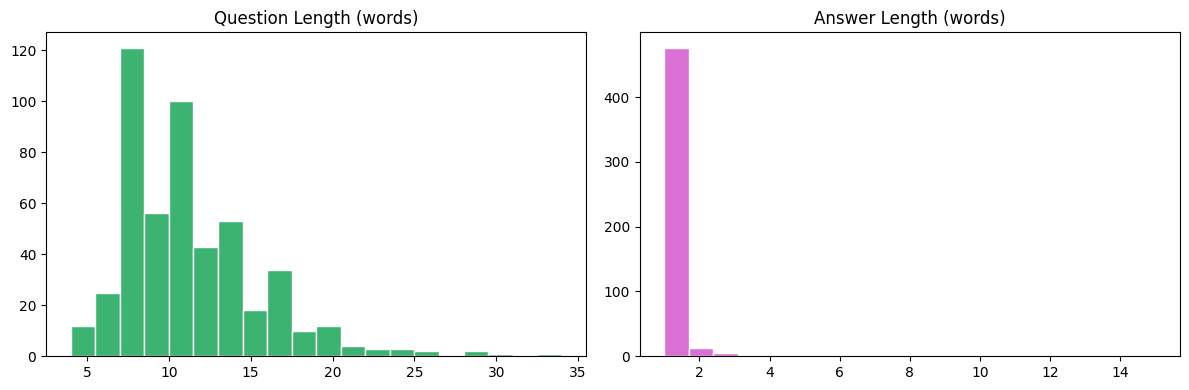

In [6]:
q_lens, a_lens = [], []
for sample in train_ds.select(range(500)):
    q_lens.append(len(sample['query'].split()))
    label = sample['label'][0] if isinstance(sample['label'], list) else sample['label']
    a_lens.append(len(str(label).split()))

print(f"Question length — avg: {sum(q_lens)/len(q_lens):.1f} words, max: {max(q_lens)}")
print(f"Answer length   — avg: {sum(a_lens)/len(a_lens):.1f} words, max: {max(a_lens)}")
print(f"\n→ Answers are very short (mostly 1-3 words/numbers). Good for VQA.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(q_lens, bins=20, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Question Length (words)')
axes[1].hist(a_lens, bins=20, color='orchid', edgecolor='white')
axes[1].set_title('Answer Length (words)')
plt.tight_layout()
plt.savefig("length_distribution.png", dpi=100)
plt.show()

## 5. Check human_or_machine Column

In [7]:
from collections import Counter

if 'human_or_machine' in train_ds.column_names:
    counts = Counter(train_ds['human_or_machine'])
    print("Question source breakdown:")
    for k, v in counts.items():
        print(f"  {k}: {v} ({100*v/len(train_ds):.1f}%)")
    print("\n→ We use ALL questions regardless of source (human + machine).")
    print("  This maximizes training data diversity.")
else:
    print("No human_or_machine column in this split.")

Question source breakdown:
  0: 7398 (26.1%)
  1: 20901 (73.9%)

→ We use ALL questions regardless of source (human + machine).
  This maximizes training data diversity.


## 6. Validate Preprocessing Pipeline

Show exactly what the model sees after preprocessing — the formatted prompt that will be fed to SmolVLM.

In [8]:
!pip install -q transformers==4.49.0

from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")

sample = train_ds[0]
image = sample['image']
label = sample['label'][0] if isinstance(sample['label'], list) else sample['label']

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": f"Look at this chart and answer the question.\n\nQuestion: {sample['query']}\nAnswer:"}
        ]
    },
    {
        "role": "assistant",
        "content": [{"type": "text", "text": str(label)}]
    }
]

formatted = processor.apply_chat_template(messages, tokenize=False)

print("=" * 60)
print("RAW SAMPLE:")
print(f"  Query : {sample['query']}")
print(f"  Label : {label}")
print()
print("FORMATTED PROMPT (what the model sees):")
print(formatted)
print("=" * 60)

# Also check tokenized length
inputs = processor(
    text=[formatted],
    images=[[image]],
    return_tensors="pt"
)
print(f"\nTokenized input length: {inputs['input_ids'].shape[1]} tokens")
print("→ Our max_length=512 safely covers this.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 70.2 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 87.8 MB/s eta 0:00:00:00:01


2026-03-15 01:34:32.235985: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773538472.421347      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773538472.481268      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773538472.956068      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773538472.956105      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773538472.956108      55 computation_placer.cc:177] computation placer alr

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

RAW SAMPLE:
  Query : Is the value of Favorable 38 in 2015?
  Label : Yes

FORMATTED PROMPT (what the model sees):
<|im_start|>User:<image>Look at this chart and answer the question.

Question: Is the value of Favorable 38 in 2015?
Answer:<end_of_utterance>
Assistant: Yes<end_of_utterance>


Tokenized input length: 1170 tokens
→ Our max_length=512 safely covers this.


## 7. Preprocessing Decisions Summary

| Decision | Choice | Reason |
|---|---|---|
| Image handling | Pass PIL image directly | SmolVLM processor handles resizing internally |
| Prompt format | Chat template (user/assistant) | Matches SmolVLM-Instruct training format |
| Label handling | `label[0]` if list, else `str(label)` | ChartQA stores labels as lists sometimes |
| Columns used | image, query, label | `human_or_machine` not needed for training |
| Max token length | 512 | Covers 99%+ of samples, fits T4 VRAM |
| Train subset | 2000 samples | Balances training time vs quality on T4 |
| Val subset | 200 samples | Enough to track generalization |

**Proceed to `02_training.ipynb` to fine-tune the model.**